In [14]:
import pandas as pd
df = pd.read_csv("data/NF-UNSW-NB15-v3.csv")

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

X = df.drop(columns=["Label"])
X.to_csv("data/X.csv", index=False)

In [15]:
import pandas as pd
# Use this if necessary
X_processed = pd.read_csv("data/X_processed.csv")
y = pd.read_csv("data/y.csv")

In [18]:
X_processed

,L4_SRC_PORT,L4_DST_PORT,L7_PROTO,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,PROTOCOL_0,PROTOCOL_1,PROTOCOL_2,PROTOCOL_3,...,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV
0,30,339951,94,0,0,39630,False,False,False,True,...,0.009374,0.009374,0.0,-0.439769,0.000000,-0.193426,0.0,-0.437429,0.000000,-0.185449
1,50,18,6,817,108,0,False,False,False,False,...,0.009374,0.009374,0.0,0.582140,0.925110,0.642549,0.0,0.576585,0.925110,0.616048
2,32,115660,71,827,111,0,False,False,False,False,...,0.009373,0.009374,0.0,1.259655,0.864858,1.142549,0.0,1.252953,0.646241,1.015469
3,54,339951,94,0,0,24435,False,False,False,True,...,0.009374,0.009374,0.0,-0.439769,0.000000,-0.193426,0.0,-0.437429,0.000000,-0.185449
4,25,339951,94,0,0,51700,False,False,False,True,...,0.009374,0.009374,0.0,-0.439769,0.000000,-0.193426,0.0,-0.437429,0.000000,-0.185449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300503,45,80366,71,384,13,0,False,False,False,False,...,-0.981014,-0.981013,0.0,0.532935,0.750000,0.669145,0.0,0.533117,0.864858,0.686243
2300504,34,110004,71,1124,174,0,False,False,False,False,...,-0.981014,-0.981013,0.0,-0.283120,0.000000,-0.193426,0.0,-0.281614,0.000000,-0.185449
2300505,31,114,71,898,127,0,False,False,False,False,...,-0.981014,-0.981013,0.0,0.726160,1.021866,0.880978,0.0,0.723584,1.372963,0.943465
2300506,24,339951,94,0,0,17523,False,False,False,True,...,-0.981014,-0.981013,0.0,-0.439769,0.000000,-0.193426,0.0,-0.437429,0.000000,-0.185449


In [19]:
X_ip = X[["IPV4_SRC_ADDR", "IPV4_DST_ADDR"]]
X_ip

,IPV4_SRC_ADDR,IPV4_DST_ADDR
0,59.166.0.2,149.171.126.3
1,59.166.0.4,149.171.126.6
2,59.166.0.0,149.171.126.9
3,59.166.0.8,149.171.126.7
4,59.166.0.1,149.171.126.1
...,...,...
2365419,59.166.0.6,149.171.126.8
2365420,59.166.0.2,149.171.126.1
2365421,59.166.0.2,149.171.126.2
2365422,59.166.0.3,149.171.126.5


In [21]:
y

,Label
0,0
1,0
2,0
3,0
4,0
...,...
2300503,0
2300504,0
2300505,0
2300506,0


In [23]:
packet_pairs_df = pd.concat([X_ip.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
packet_pairs_df

,IPV4_SRC_ADDR,IPV4_DST_ADDR,Label
0,59.166.0.2,149.171.126.3,0
1,59.166.0.4,149.171.126.6,0
2,59.166.0.0,149.171.126.9,0
3,59.166.0.8,149.171.126.7,0
4,59.166.0.1,149.171.126.1,0
...,...,...,...
2300503,59.166.0.6,149.171.126.8,0
2300504,59.166.0.2,149.171.126.1,0
2300505,59.166.0.2,149.171.126.2,0
2300506,59.166.0.3,149.171.126.5,0


In [ ]:
## Compute number of Benign and Malicious packets from each Source and Destination IP address
pair_counts = (
    packet_pairs_df
    .groupby(["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "Label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={0: "benign_count", 1: "malicious_count"})
)

pair_counts


Label,IPV4_SRC_ADDR,IPV4_DST_ADDR,benign_count,malicious_count
0,10.40.182.1,10.40.198.10,4,0
1,10.40.182.1,224.0.0.5,637,0
2,10.40.85.1,175.45.176.0,2,0
3,10.40.85.1,175.45.176.1,2,0
4,10.40.85.1,175.45.176.2,3,0
...,...,...,...,...
285,59.166.0.9,149.171.126.5,22250,0
286,59.166.0.9,149.171.126.6,20969,0
287,59.166.0.9,149.171.126.7,20786,0
288,59.166.0.9,149.171.126.8,20600,0


In [ ]:
pair_counts["total"] = pair_counts["benign_count"] + pair_counts["malicious_count"]
pair_counts["malicious_ratio"] = pair_counts["malicious_count"] / pair_counts["total"]

In [33]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\josia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
import networkx as nx

G = nx.DiGraph()  # directed: src -> dst

for _, row in pair_counts.iterrows():
    if row["malicious_count"] > 0:
        G.add_edge(row["IPV4_SRC_ADDR"], row["IPV4_DST_ADDR"], 
                   weight=row["malicious_ratio"])


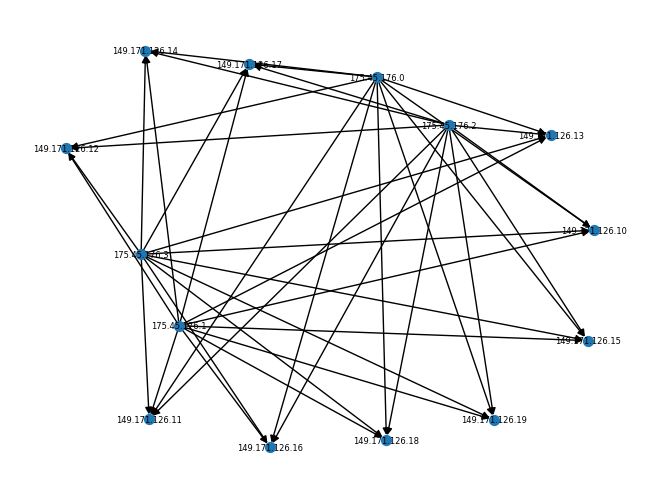

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30,30))
weights = [G[u][v]["weight"] for u, v in G.edges()]
pos = nx.spring_layout(G, k=3, seed=42)

nx.draw(G, pos, with_labels=True, width=[w / max(weights)  for w in weights],
        node_size=50, font_size=6, arrows=True)
plt.show()